In [1]:
# In this code, we generate the data locally so that we may speed up the processing of data in the learning process. 

import tensorflow as tf
from dataGenNew import rand_En, rand_theta, rand_phi, full_measure 
import numpy as np
import time
import matplotlib.pyplot as plt
import os


# Define some initial parameters for the gneration process

num_of_examples = 1.e3
res = 128
n_coeff=10
noise = 0.01

filename = "dataset_128by128_1e3"


In [62]:
# Guard against permission denied error

assert os.path.isfile(filename)
with open(filename, "r") as f:
    pass


AssertionError: 

# Let's check that our training example looks good

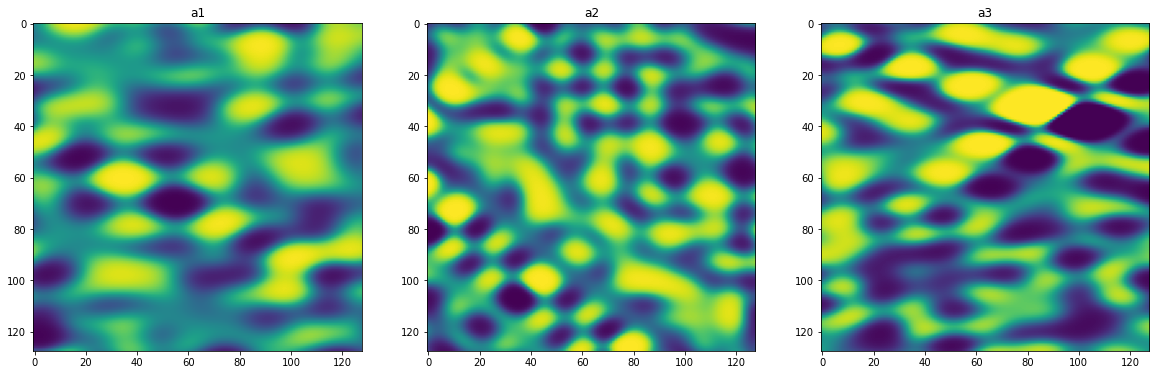

In [2]:
# Let's generate one example 

a1=rand_En(n_coeff,res)
a2=rand_theta(n_coeff,res)
a3=rand_phi(n_coeff,res)
            
if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
    a2=np.pi-a2
        
X =full_measure(a1,a2,a3,res,noise)

# Plot the distributions of the unitary maps

fig,  ax = plt.subplots(1,3,figsize=(20,20))


ax[0].imshow(a1)
ax[1].imshow(a2)
ax[2].imshow(a3)


ax[0].set_title('a1')
ax[1].set_title('a2')
ax[2].set_title('a3')

plt.savefig('sample_unitary.png')



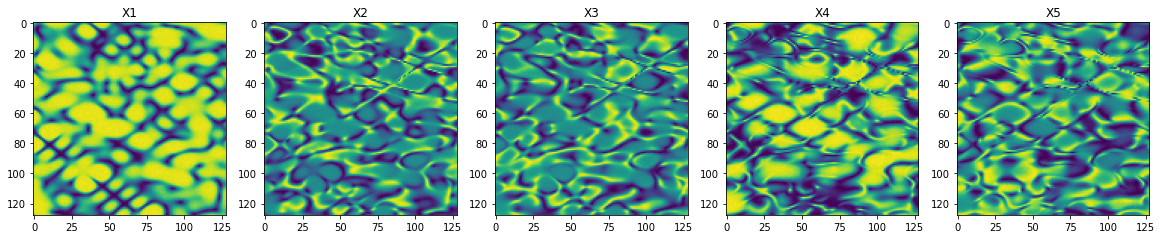

In [3]:
# Plot the distributions of the polametric measuremenets

# Plot the distributions of the unitary maps

fig,  ax = plt.subplots(1,5,figsize=(20,20))


ax[0].imshow(X[:,:,0])
ax[1].imshow(X[:,:,1])
ax[2].imshow(X[:,:,2])
ax[3].imshow(X[:,:,3])
ax[4].imshow(X[:,:,4])


ax[0].set_title('X1')
ax[1].set_title('X2')
ax[2].set_title('X3')
ax[3].set_title('X4')
ax[4].set_title('X5')

plt.savefig('sample_pol_measure.png')


# Generating Many Examples

In [4]:
import pickle

# Now to generate many examples

X = np.empty((int(num_of_examples), res, res, 5))
y = np.empty((int(num_of_examples),res, res, 3))
    

for ii in range(int(num_of_examples)):
    
    a1=rand_En(n_coeff,res)
    a2=rand_theta(n_coeff,res)
    a3=rand_phi(n_coeff,res)
            
    if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
        a2=np.pi-a2
        
    y[ii,:,:,0] = a1
    y[ii,:,:,1] = a2
    y[ii,:,:,2] = a3
        
    X[ii] = full_measure(a1,a2,a3,res,noise)
    
    
    if ii % 100 == 0:
        print('Training data: ', ii, '/', num_of_examples)
        
with open(filename + '.pkl', 'wb') as f:
    pickle.dump([X, y], f)
        
print("Done!!")


Training data:  0 / 1000.0


KeyboardInterrupt: 